In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

In [ ]:
# =============================================================================
# USER CONFIGURATION -- BC_10x
# =============================================================================

SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/BC_10x/data")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_10x_spacross")

CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_BC_10X_SAMPLES = [
    "1142243F",
    "1160920F",
    "CID4290",
    "CID4465",
    "CID44971",
    "CID4535",
]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

BC_10X_NUM_CLUSTERS = 6

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_BC_10X_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

In [3]:
# =============================================================================
# Data loading -- BC_10x-specific
# =============================================================================
def load_bc_10x_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index

In [4]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    num_clusters = BC_10X_NUM_CLUSTERS
    
    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "dataset": "BC_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "NMI": float(NMI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "BC_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

In [5]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross BC_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "BC_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_BC_10X}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, edge_index = load_bc_10x_sample(config, sample_id, TOOLS)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-12 23:20:01,116 [INFO] Log file: /home/dal875013/work/projects/mocha/results/bc_10x_spacross/benchmark.log
2026-05-12 23:20:01,116 [INFO] ========================================================================
2026-05-12 23:20:01,117 [INFO] SpaCross BC_10x Benchmarking Framework
2026-05-12 23:20:01,117 [INFO] ========================================================================


2026-05-12 23:20:07,436 [INFO] cffi mode is CFFI_MODE.ANY
2026-05-12 23:20:07,614 [INFO] R home found: /work/dal875013/conda_envs/spacross_env/lib/R
2026-05-12 23:20:08,938 [INFO] R library path: /work/dal875013/conda_envs/spacross_env/lib:
2026-05-12 23:20:08,940 [INFO] LD_LIBRARY_PATH: /work/dal875013/conda_envs/spacross_env/lib
2026-05-12 23:20:08,962 [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2026-05-12 23:20:09,711 [INFO] R is already initialized. No need to initialize.
2026-05-12 23:20:12,070 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-12 23:20:12,107 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-05-12 23:20:12,108 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-05-12 23:20:12,117 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-05-12 23:20:12,119 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/BC_10x/data
2026-05-12 23:20:12,124 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/bc_

NameError: name 'NUM_CLUSTERS_BC_10X' is not defined

SAMPLE_ID = CID44971
n spots in adata      : 1160
n predictions matched : 1160


... storing 'true_label' as categorical
... storing 'pred_label' as categorical


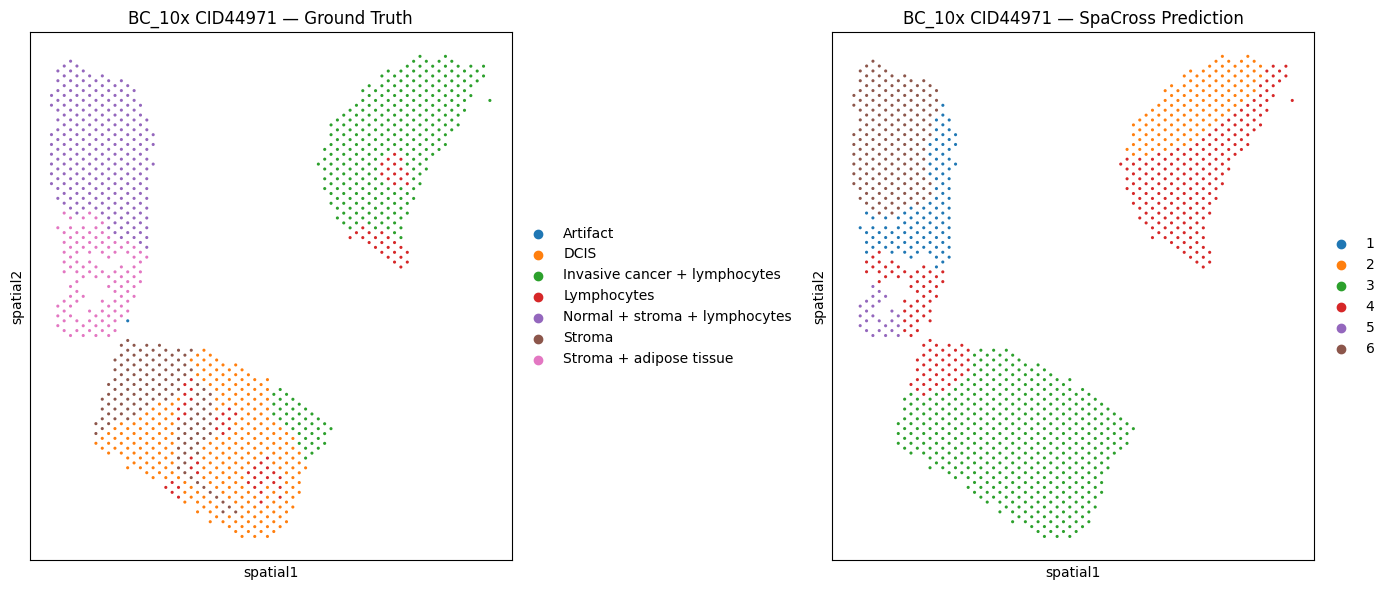

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/BC_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_10x_spacross")

SAMPLE_ID = "CID44971"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"BC_10x {SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"BC_10x {SAMPLE_ID} — SpaCross Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/bc_10x_spacross")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance["sample"] = performance["sample"].astype(str)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All BC_10x SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "running_time_sec"] if c in performance.columns]
display(performance[summary_cols].describe())

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All BC_10x SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,BC_10x,1142243F,0,0.064009,0.088275,0.095089,0.037928,6,4784,4784,38.87,mclust,NVIDIA A30
1,BC_10x,1160920F,0,0.184141,0.310727,0.321037,0.033009,6,4895,4894,25.13,mclust,NVIDIA A30
2,BC_10x,CID4290,0,0.054874,0.169401,0.210903,0.047545,6,2426,2426,30.01,mclust,NVIDIA A30
3,BC_10x,CID4465,0,0.046114,0.153718,0.258701,0.037414,6,1211,1211,16.91,mclust,NVIDIA A30
4,BC_10x,CID44971,0,0.422236,0.570105,0.570992,0.034801,6,1160,1160,19.07,mclust,NVIDIA A30
5,BC_10x,CID4535,0,0.382364,0.461835,0.463349,0.039743,6,1125,1051,17.99,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,0.192289,0.292344,0.320012,0.038407,24.663333
std,0.170749,0.190889,0.173085,0.005073,8.562324
min,0.046114,0.088275,0.095089,0.033009,16.910000
25%,0.057157,0.157639,0.222853,0.035454,18.260000
50%,0.124075,0.240064,0.289869,0.037671,22.100000
75%,0.332808,0.424058,0.427771,0.039289,28.790000
max,0.422236,0.570105,0.570992,0.047545,38.870000



===== Mean metrics =====
Mean ARI: 0.1923
Mean NMI: 0.2923
Mean ACC: 0.3200
Mean DIS: 0.0384

===== Best / worst ARI =====
Best ARI : CID44971  ARI=0.4222
Worst ARI: CID4465  ARI=0.0461


In [ ]:
# actual layer in ground truth checking
import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/BC_10x/data")

ALL_BC_10X_SAMPLES = [
    "1142243F",
    "1160920F",
    "CID4290",
    "CID4465",
    "CID44971",
    "CID4535",
]

results = []

for sample_id in ALL_BC_10X_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels_all = adata.obs["z"]

    # 去掉 NaN
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

# 转成 dataframe
df = pd.DataFrame(results).sort_values("n_classes")

print("===== BC_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)

===== BC_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
3,CID4465,4,"[Artifact, Invasive cancer + stroma + lymphocy...",1211,1211,0
2,CID4290,4,"[Artifact, Invasive cancer + stroma, Invasive ...",2426,2426,0
0,1142243F,6,"[Artifact, Invasive cancer + stroma + lymphocy...",4784,4784,0
4,CID44971,7,"[Artifact, DCIS, Invasive cancer + lymphocytes...",1160,1160,0
5,CID4535,7,"[Adipose tissue, Artifact, Invasive cancer, In...",1125,1051,74
1,1160920F,8,"[Adipose tissue, Artifact, Cancer trapped in l...",4895,4894,1



===== Summary =====
n_classes
4    2
6    1
7    2
8    1
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'CID4465': 4, 'CID4290': 4, '1142243F': 6, 'CID44971': 7, 'CID4535': 7, '1160920F': 8}
